/kaggle/input/datasets/rohithmahadevan/canada-employment-trend-cycle-dataset-official/14100355_MetaData.csv
/kaggle/input/datasets/rohithmahadevan/canada-employment-trend-cycle-dataset-official/14100355.csv


/tmp/ipykernel_58/3497690192.py:25: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/datasets/rohithmahadevan/canada-employment-trend-cycle-dataset-official/14100355.csv")


Shape: (600096, 17)

Columns:
['REF_DATE', 'GEO', 'DGUID', 'North American Industry Classification System (NAICS)', 'Statistics', 'Data type', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']
['Total employed, all industries' 'Goods-producing sector'
 'Agriculture [111-112, 1100, 1151-1152]'
 'Forestry, fishing, mining, quarrying, oil and gas [21, 113-114, 1153, 2100]'
 'Utilities [22]' 'Construction [23]' 'Manufacturing [31-33]'
 'Services-producing sector' 'Wholesale and retail trade [41, 44-45]'
 'Transportation and warehousing [48-49]'
 'Finance, insurance, real estate, rental and leasing [52-53]'
 'Professional, scientific and technical services [54]'
 'Business, building and other support services [55-56]'
 'Educational services [61]' 'Health care and social assistance [62]'
 'Information, culture and recreation [51, 71]'
 'Accommodation and food services [72]'
 'Other services (except public administrat

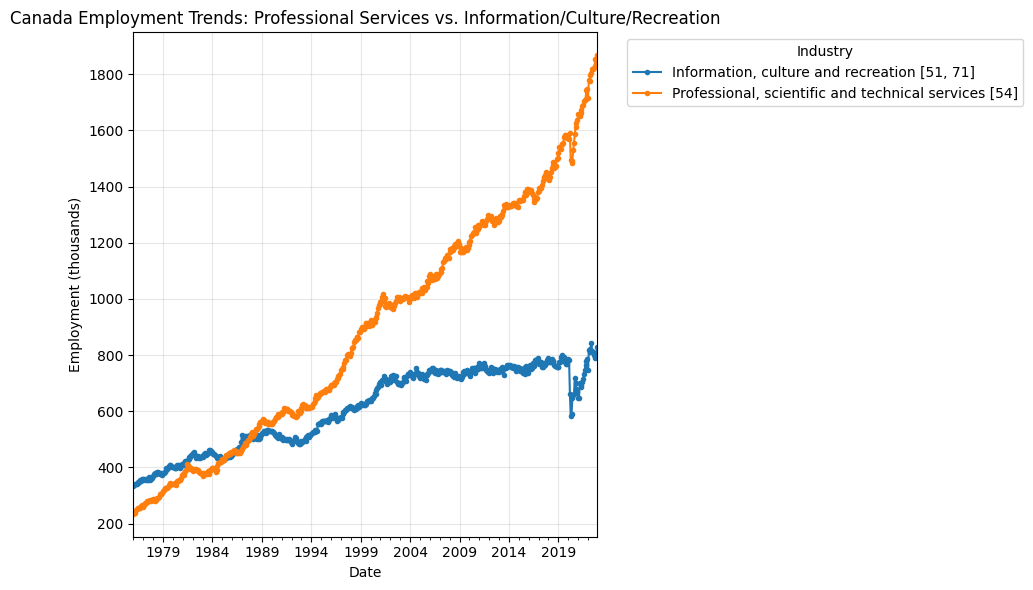

In [31]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

df = pd.read_csv("/kaggle/input/datasets/rohithmahadevan/canada-employment-trend-cycle-dataset-official/14100355.csv")


print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
# print("\nFirst 5 rows:")
df.head()



# ============================================
# STEP 2: See what industries actually exist
# ============================================
print(df["North American Industry Classification System (NAICS)"].unique())

# ============================================
# STEP 3: Filter to Canada, Seasonally adjusted, Estimate, your industry
# ============================================
#target_industry1 = "Total employed, all industries"  # ← replace once you see real options
#target_industry2 ="Information, culture and recreation [51, 71]"

target_industries = [
    "Professional, scientific and technical services [54]"
    ,"Information, culture and recreation [51, 71]"
]

df_filtered = df[
    (df["GEO"] == "Canada") &
    (df["North American Industry Classification System (NAICS)"].isin(target_industries))&
    (df["Statistics"] == "Estimate") &
    (df["Data type"] == "Seasonally adjusted")
].copy()

print(df_filtered.shape)
df_filtered.head()


# ============================================
# STEP 4: Parse the date properly (monthly format)
# ============================================
df_filtered["REF_DATE"] = pd.to_datetime(df_filtered["REF_DATE"], format="%Y-%m")
df_filtered.tail(20)  # most recent 20 months

pivot = df_filtered.pivot_table(
    index="REF_DATE",
    columns="North American Industry Classification System (NAICS)",
    values="VALUE"
).sort_index()

pivot.tail(12)

growth = ((pivot.iloc[-1] - pivot.iloc[0]) / pivot.iloc[0] * 100).round(1)
print(growth)

#
# STEP 5: Plot
#

import matplotlib.pyplot as plt

pivot.plot(figsize=(10, 6), marker="o", markersize=3)
plt.title("Canada Employment Trends: Professional Services vs. Information/Culture/Recreation")
plt.xlabel("Date")
plt.ylabel("Employment (thousands)")
plt.legend(title="Industry", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("canada_employment_comparison.png", dpi=150)
plt.show()